In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

True

In [3]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [4]:
class ModernState(TypedDict):
    post_content: str
    user_reputation: str

    formatted_post: str
    content_flag: str
    result: str

In [5]:
def format_post(state: ModernState):
    # mirrors show_equation from the original
    formatted = f"User ({state['user_reputation']}) says {state['post_content']}"
    return {'formatted_post': formatted}

def analyzed_content(state: ModernState):
    content = state['post_content'].lower()
    if 'spam' in content or 'buy now' in content:
        flag = 'rejected'
    elif state['user_reputation'] == 'new_user':
        flag = 'review'
    else:
        flag = 'approved'
    return {'content_flag': flag}


def approve_post(state: ModernState):
    result = 'Post published successfully to the timeline'
    return {'result': result}

def flag_for_review(state: ModernState):
    result = 'Post sent to the human moderation queue.'
    return {'result': result}

def reject_post(state: ModernState):
    result = 'Post automatically deleted due to policy violation.'
    return {'result': result}

In [17]:
def check_condition(state: ModernState)-> Literal['approve_post', 'flag_for_review', 'reject_post']:
    if state['content_flag'] == 'approved':
        return 'approve_post'
    elif state['content_flag'] == 'review':
        return 'flag_for_review'
    else:
        return 'reject_post'

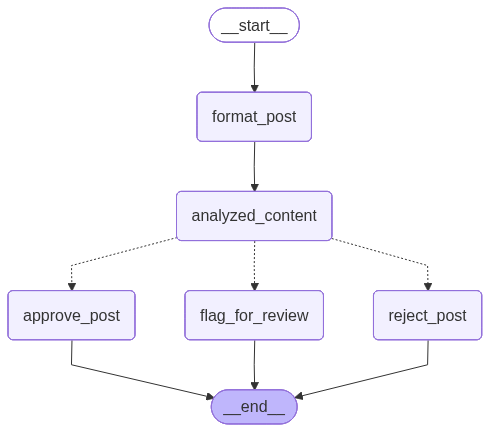

In [18]:
graph = StateGraph(ModernState)

graph.add_node('format_post', format_post)
graph.add_node('analyzed_content', analyzed_content)
graph.add_node('approve_post', approve_post)
graph.add_node('flag_for_review', flag_for_review)
graph.add_node('reject_post', reject_post)


graph.add_edge(START, 'format_post')
graph.add_edge('format_post', 'analyzed_content')

graph.add_conditional_edges('analyzed_content', check_condition)

graph.add_edge('approve_post', END)
graph.add_edge('flag_for_review', END)
graph.add_edge('reject_post', END)

workflow = graph.compile()
workflow

In [19]:
initial_state = {
    'post_content': 'Check out this amazing product! Buy now!',
    'user_reputation': 'trusted_user'}

final_state = workflow.invoke(initial_state)
final_state



{'post_content': 'Check out this amazing product! Buy now!',
 'user_reputation': 'trusted_user',
 'formatted_post': 'User (trusted_user) says Check out this amazing product! Buy now!',
 'content_flag': 'rejected',
 'result': 'Post automatically deleted due to policy violation.'}

In [20]:
initial_state = {
    'post_content': 'Check out this amazing product!',
    'user_reputation': 'trusted_user'}

final_state = workflow.invoke(initial_state)
final_state

{'post_content': 'Check out this amazing product!',
 'user_reputation': 'trusted_user',
 'formatted_post': 'User (trusted_user) says Check out this amazing product!',
 'content_flag': 'approved',
 'result': 'Post published successfully to the timeline'}

In [21]:
initial_state = {
    'post_content': 'Check out this amazing product! Buy now!',
    'user_reputation': 'new_user'}

final_state = workflow.invoke(initial_state)
final_state

{'post_content': 'Check out this amazing product! Buy now!',
 'user_reputation': 'new_user',
 'formatted_post': 'User (new_user) says Check out this amazing product! Buy now!',
 'content_flag': 'rejected',
 'result': 'Post automatically deleted due to policy violation.'}